<a href="https://colab.research.google.com/github/Wajid0005/CAMPUS-X-notebooks/blob/main/task_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
import plotly.express as px

###`Q 1-3` Using the 'diamonds' dataset - sns.load_dataset('diamonds')
1. Create a violinplot of 'price' grouped by 'cut'.
2. Create regplot on `carat` vs `price`. and give hue on 'cut'
3. Create boxplot on 'color' and 'price'

In [9]:
df = sns.load_dataset('diamonds')
df.shape

(53940, 10)

In [23]:
temp = df.groupby('cut')['price'].mean()
temp

/tmp/ipykernel_7998/3743197882.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,price
cut,
Ideal,3457.541970
Premium,4584.257704
Very Good,3981.759891
Good,3928.864452
Fair,4358.757764


<Axes: xlabel='cut', ylabel='price'>

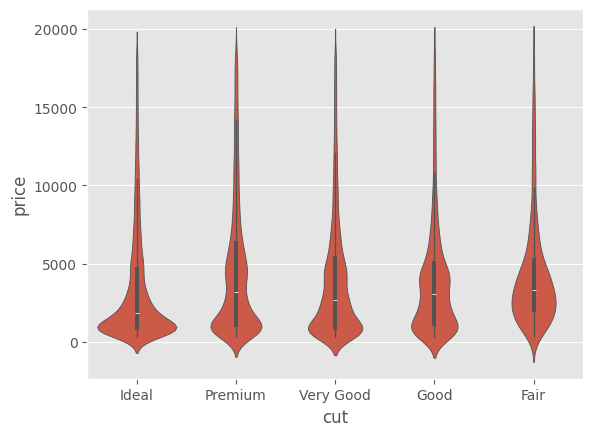

In [25]:
#1
temp
sns.violinplot(
    df,
    x = 'cut',
    y = 'price'
)

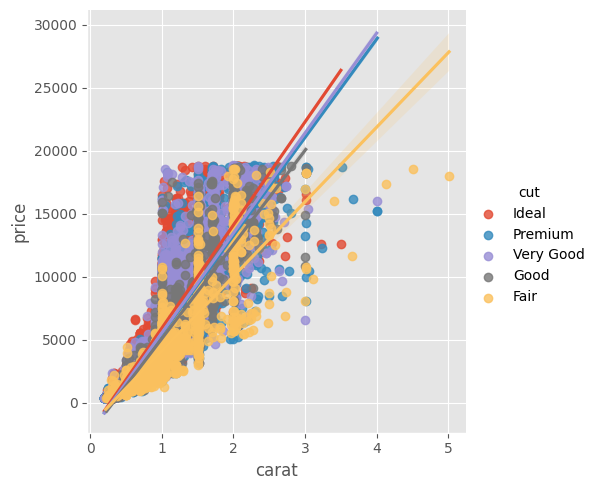

In [29]:
from matplotlib import colors
#2 Create regplot on carat vs price. and give hue on 'cut
sns.lmplot(
    df,
    x = 'carat',
    y = 'price',
    hue = 'cut'
)


In [30]:
#3 Create boxplot on 'color' and 'price'
px.box(
    df,
    x = 'color',
    y = 'price'
)

###`Q 4` Using the 'Taxis' dataset - sns.load_dataset('taxis')
4.1. Create a categorical estimate plot of the totl fare - 'total' for each payment type - 'payment'.

4.2. Create a regression plot on time of ride  vs total fare. You will need to calculate ride time using pickup and dropoff column.

4.3 Give hue on payment type. and Another plot hue on taxi 'color'. Observe the plot.

In [34]:
df  =sns.load_dataset('taxis')
df.payment.unique()

array(['credit card', 'cash', nan], dtype=object)

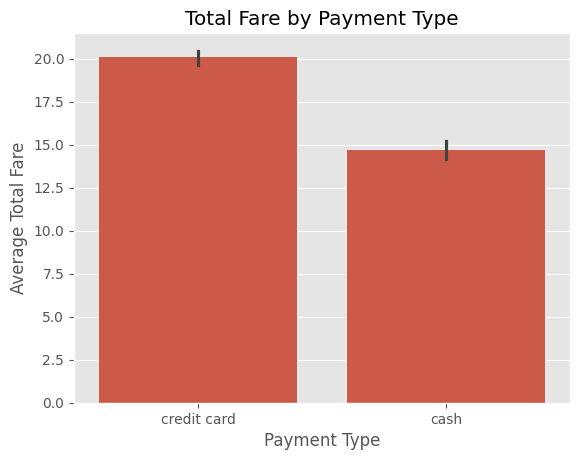

In [44]:
#4.1 Create a categorical estimate plot of the totl fare
# - 'total' for each payment type - 'payment'.
sns.barplot(
    data = df,
    x = 'payment',
    y = 'total',
    estimator= 'mean'
)
plt.title('Total Fare by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Average Total Fare')
plt.show()


In [40]:
#4.2 Create a regression plot on time of ride vs total fare.
#You will need to calculate ride time using pickup and dropoff column.
df['trip_time'] = df['dropoff'] - df['pickup']

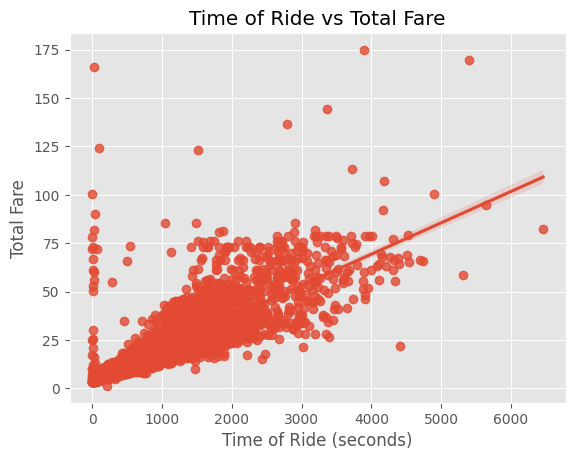

In [43]:
sns.regplot(
    df,
    x = df['trip_time'].dt.total_seconds(), # Convert timedelta to seconds
    y = 'total'
)
plt.title('Time of Ride vs Total Fare')
plt.xlabel('Time of Ride (seconds)')
plt.ylabel('Total Fare')
plt.show()

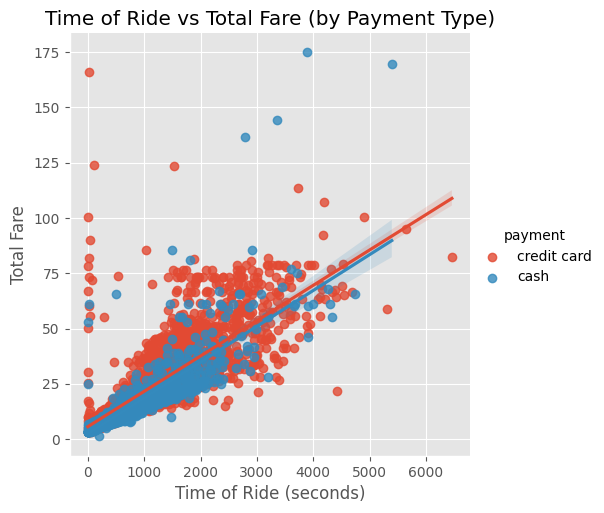

In [51]:
#4.3 Give hue on payment type. and Another plot hue
# on taxi 'color'. Observe the plot.

df['trip_time_seconds'] = df['trip_time'].dt.total_seconds()

sns.lmplot(
    data = df,
    x = 'trip_time_seconds',
    y = 'total',
    hue= 'payment'
)
plt.title('Time of Ride vs Total Fare (by Payment Type)')
plt.xlabel('Time of Ride (seconds)')
plt.ylabel('Total Fare')
plt.show()

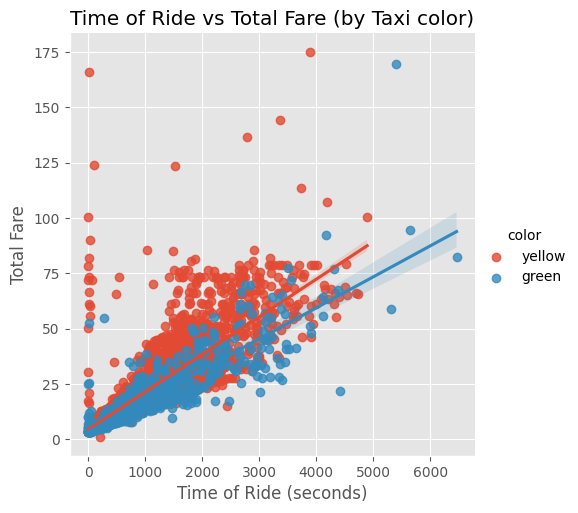

In [53]:
# on taxi 'color'. Observe the plot.

df['trip_time_seconds'] = df['trip_time'].dt.total_seconds()

sns.lmplot(
    data = df,
    x = 'trip_time_seconds',
    y = 'total',
    hue= 'color'
)
plt.title('Time of Ride vs Total Fare (by Taxi color)')
plt.xlabel('Time of Ride (seconds)')
plt.ylabel('Total Fare')
plt.show()

## Problem 5-12:

### **`Problem 5:`** Draw a strip plot and swarm plot between "gender" and "bloodpressure" w.r.t "smoker" (use as hue parameter). Also add title to the charts.

In [56]:
df = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vQVpcVtdYdZU4zU4-lqxt-iPHkyndDWs_aqEDUu9ZodlJ48Dku0PFgdXlj2N5RCmwXJrNtZLsI_wEVf/pub?gid=220677750&single=true&output=csv')
df

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...,...
1335,1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.40
1336,1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.07
1337,1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.40
1338,1338,1339,37.0,male,30.4,106,No,0,Yes,southeast,62592.87


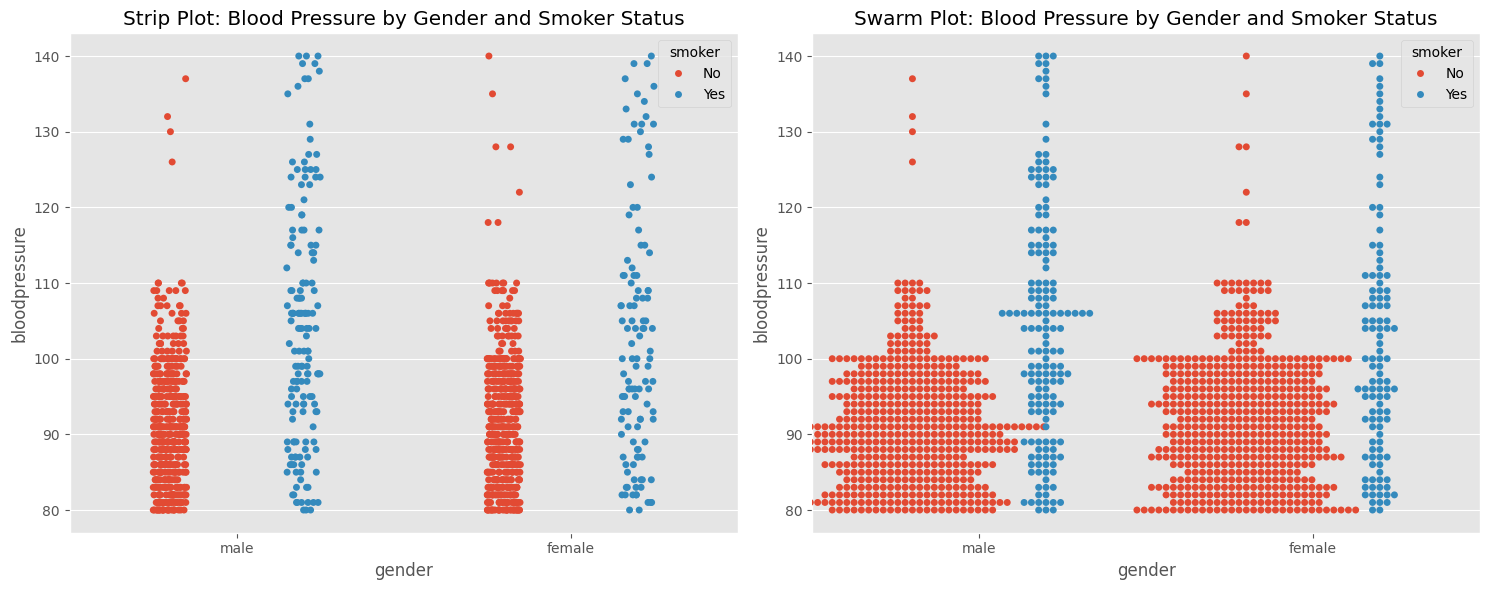

In [58]:
plt.figure(figsize=(15, 6))

plt.subplot(1,2,1)

sns.stripplot(
    data = df,
    x = 'gender',
    y= 'bloodpressure',
    hue = 'smoker',
    dodge= True
)
plt.title("Strip Plot: Blood Pressure by Gender and Smoker Status")

plt.subplot(1,2,2)

sns.swarmplot(
    data = df,
    x = 'gender',
    y= 'bloodpressure',
    hue = 'smoker',
    dodge= True
)
plt.title("Swarm Plot: Blood Pressure by Gender and Smoker Status")

plt.tight_layout()
plt.show()

### **`Problem 6:`** Draw a Box-plot and a Violin plot of which x-axis represents the "region" and the y-axis represents the "bmi". Also add extra information of the column "diabetic".

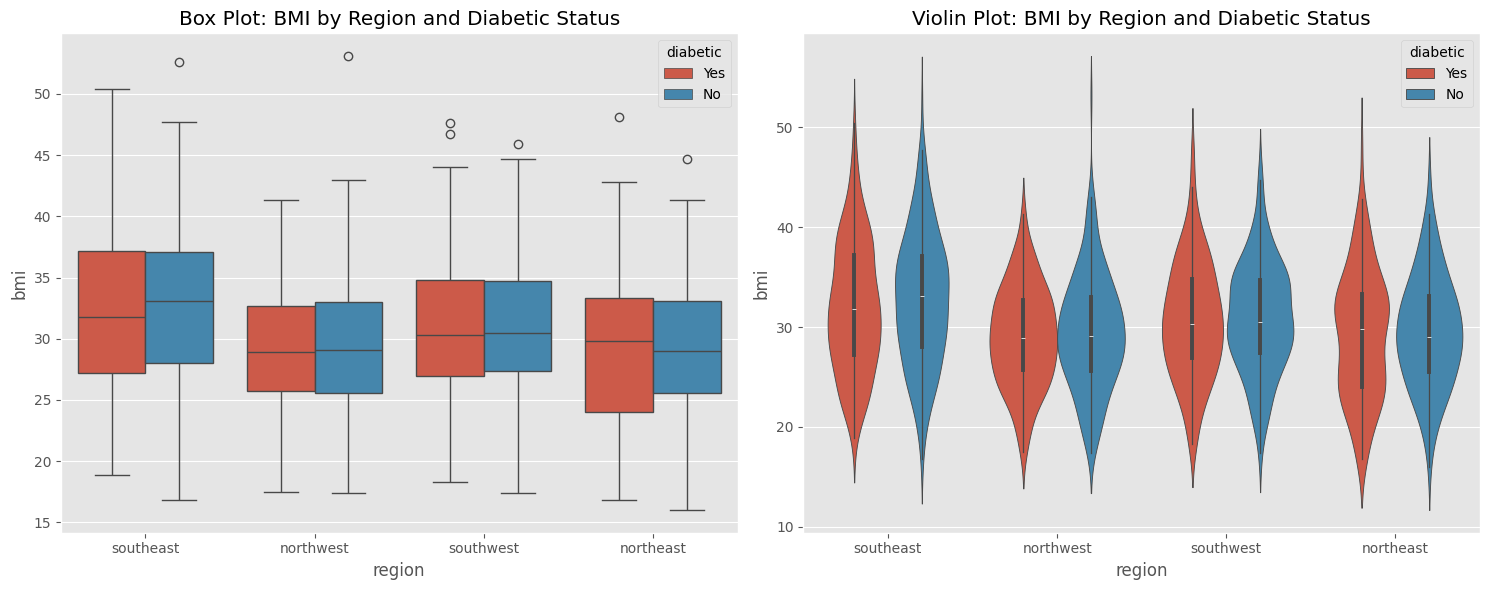

In [61]:
plt.figure(figsize=(15, 6))

plt.subplot(1,2,1)

sns.boxplot(
    data= df,
    x = 'region',
    y = 'bmi',
    hue = 'diabetic'
)
plt.title("Box Plot: BMI by Region and Diabetic Status")

plt.subplot(1,2,2)

sns.violinplot(
    data= df,
    x = 'region',
    y = 'bmi',
    hue = 'diabetic'
)
plt.title("Violin Plot: BMI by Region and Diabetic Status")

plt.tight_layout()
plt.show()


### **`Problem  7:`** Draw a bar plot and point plot of which x-axis represents the "gender" and y-axis represents "claim". Also add extra information about "smoker" column.

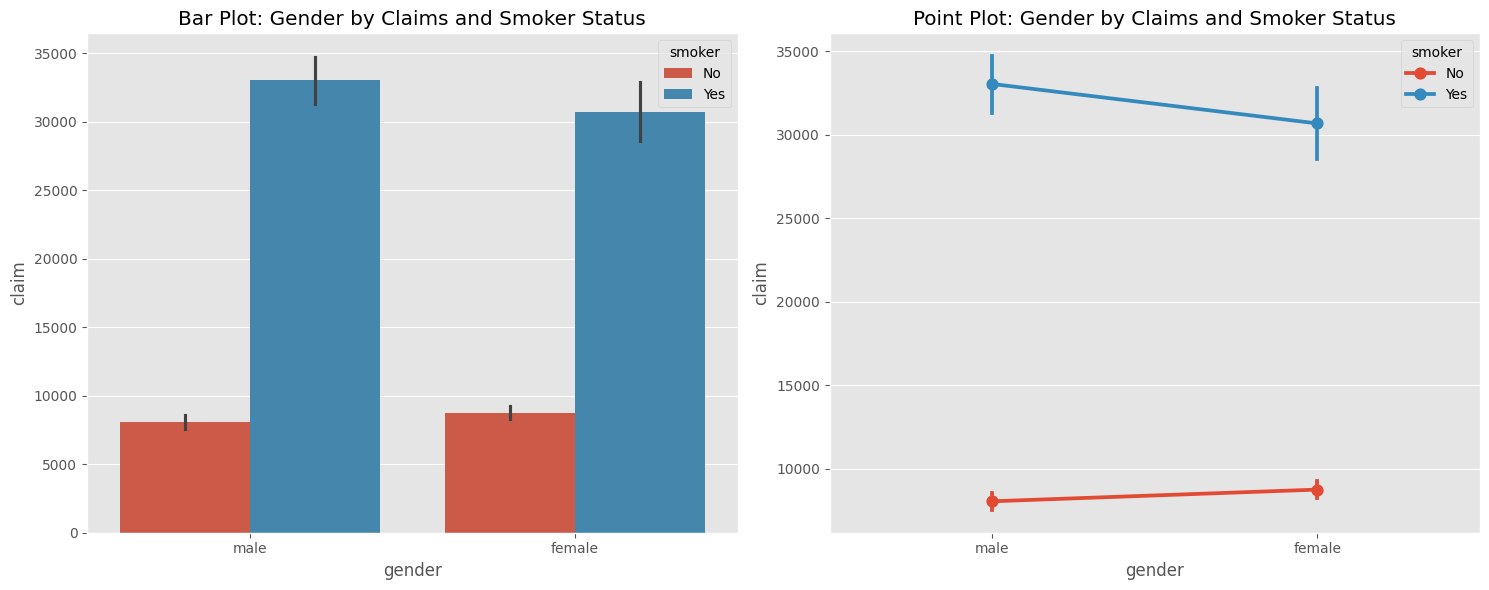

In [62]:
plt.figure(figsize=(15, 6))

plt.subplot(1,2,1)

sns.barplot(
    data= df,
    x = 'gender',
    y = 'claim',
    hue = 'smoker'
)
plt.title("Bar Plot: Gender by Claims and Smoker Status")

plt.subplot(1,2,2)

sns.pointplot(
    data= df,
    x = 'gender',
    y = 'claim',
    hue = 'smoker'
)
plt.title("Point Plot: Gender by Claims and Smoker Status")

plt.tight_layout()
plt.show()


### **`Problem 8:`** Draw a reg plot between "age" and "bmi" columns.

<Axes: xlabel='age', ylabel='bmi'>

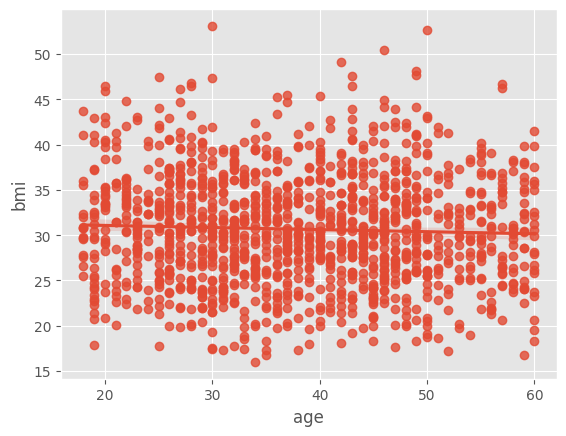

In [65]:
sns.regplot(
    data = df,
    x = 'age',
    y = 'bmi'

    )

### **`Problem 9:`** Draw a pair plot of the insurance data. Use "gender" as hue parameter.

In [66]:
df

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...,...
1335,1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.40
1336,1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.07
1337,1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.40
1338,1338,1339,37.0,male,30.4,106,No,0,Yes,southeast,62592.87


### **`Problem 10:`** Draw a pair grid of the insurance data and use "diabetic" column as a hue parameter. Also, make the diagonal plots as box-plot, upper parts as scatter plot and the lower parts as kde plot.

In [ ]:
# code here

### **`Prolem 11:`** Draw a joint plot as scatter between "bloodpressure" and "bmi". Use "smoker" as hue parameter.

In [ ]:
# code here

### **`Problem 12:`** Draw a joint grid of which x-axis represents "age" and y-axis represents "claim". Draw

In [ ]:
# code here